# NB01: Pilot Exploration — Gene Copy Number by COG Category

**Goal**: Validate the copy number extraction approach on 5 phylogenetically diverse pilot species (≥100 genomes each, ≥3 phyla). Characterize the basic distribution of copy numbers per gene cluster per genome, and check whether the L vs housekeeping pattern seen in *L. seeligeri* replicates across other species.

**Inputs**: `kbase_ke_pangenome.{gene, gene_genecluster_junction, gene_cluster, genome, eggnog_mapper_annotations, pangenome, gtdb_species_clade}`

**Outputs**: `data/pilot_copy_numbers.csv`, `data/pilot_cog_stats.csv`, `figures/pilot_cog_copy_distribution.png`

In [1]:
from berdl_notebook_utils.setup_spark_session import get_spark_session
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

spark = get_spark_session()

DATA_DIR = Path('../data')
FIG_DIR = Path('../figures')
DATA_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

## 1. Select 5 pilot species across phyla

Criteria: 100–200 genomes (enough for copy number statistics without excessive scale), diverse phyla. Prefer species already touched by other BERIL projects to leverage existing context.

In [2]:
# Curated pilot list — diverse phyla, moderate genome counts (100-200)
PILOT_SPECIES = [
    ('s__Listeria_seeligeri--RS_GCF_000027145.1', 'Bacillota'),         # 168 genomes
    ('s__Stutzerimonas_stutzeri--RS_GCF_000219605.1', 'Pseudomonadota'),  # 149 genomes
    ('s__Phocaeicola_dorei--RS_GCF_013009555.1', 'Bacteroidota'),       # 135 genomes
    ('s__Borreliella_burgdorferi--RS_GCF_000008685.2', 'Spirochaetota'), # 140 genomes
    ('s__Bifidobacterium_bifidum--RS_GCF_001025135.1', 'Actinomycetota'), # 175 genomes
]

# Verify all have expected genome counts
for sid, phylum in PILOT_SPECIES:
    prefix = sid.split('--')[0]
    r = spark.sql(f"""
        SELECT no_genomes, no_gene_clusters, no_core
        FROM kbase_ke_pangenome.pangenome
        WHERE gtdb_species_clade_id LIKE '{prefix}%'
    """).collect()
    if r:
        print(f"{phylum:20s} {prefix:60s} genomes={r[0].no_genomes:4d} clusters={r[0].no_gene_clusters:6d} core={r[0].no_core}")

Bacillota            s__Listeria_seeligeri                                        genomes= 168 clusters= 11450 core=2360


Pseudomonadota       s__Stutzerimonas_stutzeri                                    genomes= 149 clusters= 39822 core=3448


Bacteroidota         s__Phocaeicola_dorei                                         genomes= 135 clusters= 38036 core=3139


Spirochaetota        s__Borreliella_burgdorferi                                   genomes= 140 clusters=  5936 core=909


Actinomycetota       s__Bifidobacterium_bifidum                                   genomes= 175 clusters= 20371 core=1376


## 2. Extract per-genome per-cluster copy counts for each pilot species

For each species, run the 3-way join (`gene × junction × gene_cluster`) and count genes per (genome, cluster). This gives us the raw copy number matrix. We keep the results as Spark DataFrames, aggregate to per-cluster stats, then collect to pandas.

In [3]:
def extract_copy_stats(species_prefix, phylum):
    """For one species: return per-cluster copy number stats keyed by (cluster_id, COG_category).

    Definitions:
      - n_genomes_with = number of genomes carrying ≥1 copy of the cluster
      - total_copies = total gene count across all genomes for this cluster
      - mean_copies_per_carrier = total_copies / n_genomes_with (only over genomes that have it)
      - max_copies_in_one_genome = max copy count in a single genome
      - n_multicopy_genomes = number of genomes where copy_count > 1
    """
    spark.sql(f"""
        CREATE OR REPLACE TEMP VIEW copies_{phylum.lower()} AS
        SELECT 
            gc.gene_cluster_id,
            gc.is_core,
            gc.is_auxiliary,
            gc.is_singleton,
            g.genome_id,
            COUNT(*) as copy_count
        FROM kbase_ke_pangenome.gene g
        JOIN kbase_ke_pangenome.gene_genecluster_junction j ON g.gene_id = j.gene_id
        JOIN kbase_ke_pangenome.gene_cluster gc ON j.gene_cluster_id = gc.gene_cluster_id
        JOIN kbase_ke_pangenome.genome gm ON g.genome_id = gm.genome_id
        WHERE gm.gtdb_species_clade_id LIKE '{species_prefix}%'
        AND gc.gtdb_species_clade_id LIKE '{species_prefix}%'
        GROUP BY gc.gene_cluster_id, gc.is_core, gc.is_auxiliary, gc.is_singleton, g.genome_id
    """)

    # Aggregate to per-cluster stats and join COG
    result = spark.sql(f"""
        SELECT 
            c.gene_cluster_id,
            c.is_core,
            c.is_auxiliary,
            c.is_singleton,
            ann.COG_category,
            COUNT(DISTINCT c.genome_id) as n_genomes_with,
            SUM(c.copy_count) as total_copies,
            AVG(CAST(c.copy_count AS DOUBLE)) as mean_copies_per_carrier,
            MAX(c.copy_count) as max_copies_in_one_genome,
            SUM(CASE WHEN c.copy_count > 1 THEN 1 ELSE 0 END) as n_multicopy_genomes,
            STDDEV(CAST(c.copy_count AS DOUBLE)) as std_copies
        FROM copies_{phylum.lower()} c
        LEFT JOIN kbase_ke_pangenome.eggnog_mapper_annotations ann 
            ON c.gene_cluster_id = ann.query_name
        GROUP BY c.gene_cluster_id, c.is_core, c.is_auxiliary, c.is_singleton, ann.COG_category
    """).toPandas()
    result['species_prefix'] = species_prefix
    result['phylum'] = phylum
    return result


all_species_stats = []
for sid, phylum in PILOT_SPECIES:
    prefix = sid.split('--')[0]
    print(f"Extracting {phylum:20s} {prefix} ...")
    df = extract_copy_stats(prefix, phylum)
    print(f"  → {len(df):,} gene clusters")
    all_species_stats.append(df)

pilot_df = pd.concat(all_species_stats, ignore_index=True)
print(f"\nTotal cluster-COG rows across {len(PILOT_SPECIES)} pilots: {len(pilot_df):,}")
pilot_df.to_csv(DATA_DIR / 'pilot_copy_numbers.csv', index=False)
pilot_df.head()

Extracting Bacillota            s__Listeria_seeligeri ...


  → 11,450 gene clusters
Extracting Pseudomonadota       s__Stutzerimonas_stutzeri ...


  → 160,533 gene clusters
Extracting Bacteroidota         s__Phocaeicola_dorei ...


  → 38,036 gene clusters
Extracting Spirochaetota        s__Borreliella_burgdorferi ...


  → 5,936 gene clusters
Extracting Actinomycetota       s__Bifidobacterium_bifidum ...


  → 20,371 gene clusters

Total cluster-COG rows across 5 pilots: 236,326


,gene_cluster_id,is_core,is_auxiliary,is_singleton,COG_category,n_genomes_with,total_copies,mean_copies_per_carrier,max_copies_in_one_genome,n_multicopy_genomes,std_copies,species_prefix,phylum
0,NC_013891.1_1579,False,True,True,S,1,1,1.000000,1,0,NaN,s__Listeria_seeligeri,Bacillota
1,NZ_CM001051.1_2529,True,False,False,G,168,168,1.000000,1,0,0.000000,s__Listeria_seeligeri,Bacillota
2,NZ_JAAOHW010000094.1_1,False,True,True,L,1,1,1.000000,1,0,NaN,s__Listeria_seeligeri,Bacillota
3,NZ_JAARQB010000018.1_25,True,False,False,E,168,168,1.000000,1,0,0.000000,s__Listeria_seeligeri,Bacillota
4,NZ_JAARQC010000010.1_97,True,False,False,S,168,169,1.005952,2,1,0.077152,s__Listeria_seeligeri,Bacillota


## 3. Basic distribution characterization

How does copy number distribute? Mostly 1, some 2, rare 3+? What fraction of clusters are multi-copy in at least one genome?

In [4]:
# Per-species overall stats
summary = pilot_df.groupby(['phylum', 'species_prefix']).agg(
    n_clusters=('gene_cluster_id', 'nunique'),
    n_multicopy_clusters=('n_multicopy_genomes', lambda x: (x > 0).sum()),
    max_copies_ever=('max_copies_in_one_genome', 'max'),
    mean_copies_overall=('mean_copies_per_carrier', 'mean'),
).reset_index()
summary['pct_multicopy'] = summary['n_multicopy_clusters'] / summary['n_clusters'] * 100
print(summary.to_string())

           phylum              species_prefix  n_clusters  n_multicopy_clusters  max_copies_ever  mean_copies_overall  pct_multicopy
0  Actinomycetota  s__Bifidobacterium_bifidum       20371                   289               11             1.004716       1.418683
1       Bacillota       s__Listeria_seeligeri       11450                   242               15             1.007115       2.113537
2    Bacteroidota        s__Phocaeicola_dorei       38036                  1519               98             1.015028       3.993585
3  Pseudomonadota   s__Stutzerimonas_stutzeri      160533                  2044               19             1.007482       1.273258
4   Spirochaetota  s__Borreliella_burgdorferi        5936                   821                9             1.049145      13.830863


## 4. COG-stratified copy number: per-species and pooled

The key H1 test at pilot scale — do housekeeping (J, F, H, C) vs adaptive (L, V, M, S) COG categories differ in their fraction of multi-copy clusters?

In [5]:
# Single-letter COG only (drop composites and unannotated for the main comparison)
single_cog = pilot_df[
    pilot_df['COG_category'].notna() &
    (pilot_df['COG_category'].str.len() == 1) &
    (pilot_df['COG_category'] != '-')
].copy()

# Per-COG-per-species: fraction of clusters that are multi-copy in ≥1 genome
cog_species = single_cog.groupby(['phylum', 'COG_category']).agg(
    n_clusters=('gene_cluster_id', 'nunique'),
    n_multicopy=('n_multicopy_genomes', lambda x: (x > 0).sum()),
    mean_copies=('mean_copies_per_carrier', 'mean'),
).reset_index()
cog_species['pct_multicopy'] = cog_species['n_multicopy'] / cog_species['n_clusters'] * 100

# Pooled across pilots
cog_pooled = single_cog.groupby('COG_category').agg(
    n_clusters=('gene_cluster_id', 'nunique'),
    n_multicopy=('n_multicopy_genomes', lambda x: (x > 0).sum()),
    mean_copies=('mean_copies_per_carrier', 'mean'),
).reset_index()
cog_pooled['pct_multicopy'] = cog_pooled['n_multicopy'] / cog_pooled['n_clusters'] * 100
cog_pooled = cog_pooled.sort_values('pct_multicopy', ascending=False)

print('COG categories ranked by % multi-copy (pooled across 5 pilots):')
print(cog_pooled.to_string())

cog_pooled.to_csv(DATA_DIR / 'pilot_cog_stats.csv', index=False)

COG categories ranked by % multi-copy (pooled across 5 pilots):
   COG_category  n_clusters  n_multicopy  mean_copies  pct_multicopy
11            L       12623          627     1.036994       4.967124
19            U        3641          139     1.010086       3.817633
3             D        1956           48     1.004821       2.453988
2             C        8435          177     1.009668       2.098400
9             J        6045          125     1.005152       2.067825
14            O        3958           81     1.010680       2.046488
17            S       34952          712     1.005092       2.037079
5             F        3482           57     1.002925       1.636990
10            K       10181          138     1.003138       1.355466
15            P        8126          108     1.003418       1.329067
6             G        6002           78     1.002326       1.299567
20            V        3154           40     1.003577       1.268231
16            Q        2199           2

## 5. Housekeeping vs adaptive comparison

Pre-registered category assignments (from RESEARCH_PLAN.md):
- **Housekeeping**: J (translation), F (nucleotide metabolism), H (coenzyme metabolism), C (energy)
- **Adaptive**: L (replication/recombination/repair, incl. mobile elements), V (defense), M (cell wall), K (transcription)

In [6]:
HOUSEKEEPING = {'J', 'F', 'H', 'C'}
ADAPTIVE = {'L', 'V', 'M', 'K'}

def classify(c):
    if c in HOUSEKEEPING:
        return 'housekeeping'
    elif c in ADAPTIVE:
        return 'adaptive'
    return 'other'

single_cog['class'] = single_cog['COG_category'].apply(classify)

# Fraction of multi-copy clusters by class × phylum
class_phylum = single_cog[single_cog['class'] != 'other'].groupby(['phylum', 'class']).agg(
    n_clusters=('gene_cluster_id', 'nunique'),
    n_multicopy=('n_multicopy_genomes', lambda x: (x > 0).sum()),
).reset_index()
class_phylum['pct_multicopy'] = class_phylum['n_multicopy'] / class_phylum['n_clusters'] * 100

print('Multi-copy % by class × phylum:')
print(class_phylum.pivot(index='phylum', columns='class', values='pct_multicopy').round(2).to_string())

Multi-copy % by class × phylum:
class           adaptive  housekeeping
phylum                                
Actinomycetota      3.64          2.39
Bacillota           2.11          0.71
Bacteroidota        4.91          3.24
Pseudomonadota      1.82          1.61
Spirochaetota       5.80          2.92


## 6. Pilot visualization

Bar plot of % multi-copy by COG category, pooled across pilots. Housekeeping bars (J, F, H, C) should be near zero; adaptive bars (L, V, M) should be higher.

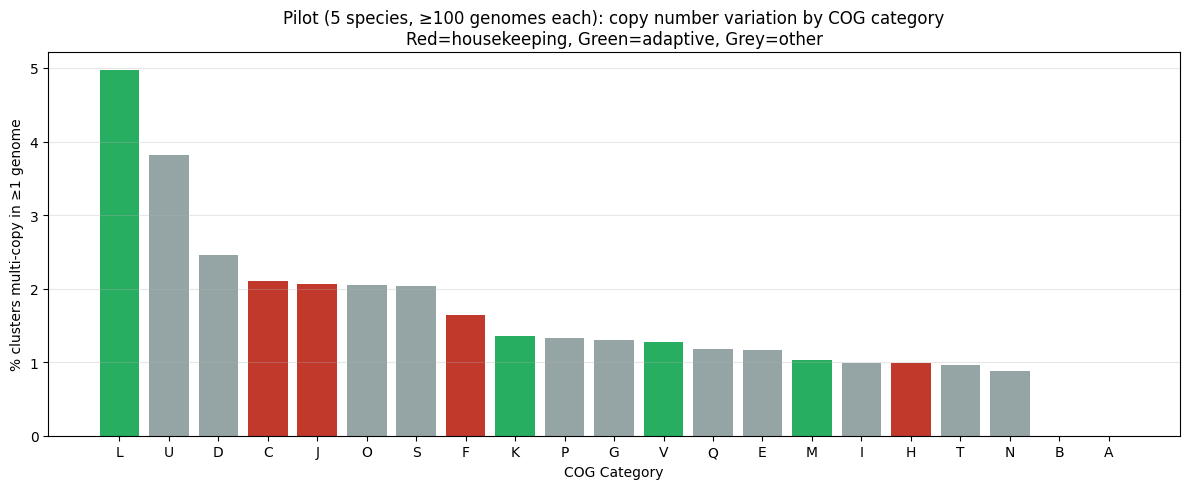

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))

colors = ['#c0392b' if c in HOUSEKEEPING else ('#27ae60' if c in ADAPTIVE else '#95a5a6')
          for c in cog_pooled['COG_category']]

ax.bar(cog_pooled['COG_category'], cog_pooled['pct_multicopy'], color=colors)
ax.set_xlabel('COG Category')
ax.set_ylabel('% clusters multi-copy in ≥1 genome')
ax.set_title('Pilot (5 species, ≥100 genomes each): copy number variation by COG category\n'
             'Red=housekeeping, Green=adaptive, Grey=other')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'pilot_cog_copy_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Pilot verdict

**Decision point for scaling to 50+ species (NB02):**
- If pooled adaptive > housekeeping by ≥3× on % multi-copy, and pattern is consistent in ≥3 of 5 pilot phyla → proceed to NB02
- If pattern is inconsistent or weak → revise operationalization (e.g., use `std_copies` instead of binary multi-copy) before scaling

In [8]:
hk_pct = single_cog[single_cog['class'] == 'housekeeping']['n_multicopy_genomes'].apply(lambda x: x > 0).mean() * 100
ad_pct = single_cog[single_cog['class'] == 'adaptive']['n_multicopy_genomes'].apply(lambda x: x > 0).mean() * 100
print(f'Pooled housekeeping % multi-copy: {hk_pct:.2f}%')
print(f'Pooled adaptive % multi-copy:     {ad_pct:.2f}%')
print(f'Ratio adaptive/housekeeping:      {(ad_pct / max(hk_pct, 0.001)):.1f}×')

n_phyla_supporting = (class_phylum.pivot(index='phylum', columns='class', values='pct_multicopy')
                      .apply(lambda row: row.get('adaptive', 0) > row.get('housekeeping', 0), axis=1)
                      .sum())
print(f'Phyla where adaptive > housekeeping: {n_phyla_supporting}/{len(PILOT_SPECIES)}')

Pooled housekeeping % multi-copy: 1.78%
Pooled adaptive % multi-copy:     2.56%
Ratio adaptive/housekeeping:      1.4×
Phyla where adaptive > housekeeping: 5/5
